<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part IV · Preparing Data &nbsp;|&nbsp; Chapter 18</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">The Data-Cleaning Mindset <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos that build the habit of inspecting before you trust: read the dtypes, scan the ranges, surface inconsistent categories, find the hidden missing codes and duplicates, and print a quick data-quality report.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Look before you trust | info / dtypes / describe surface the obvious problems |
| 2 | Categories in disguise | value_counts exposes the "Male/male/M" tangle |
| 3 | Hidden missingness | the -99 sentinel that isna() never sees |
| 4 | Dupes & impossible values | duplicated() and range checks |
| 5 | A data-quality report | one printout that audits every column |

> This chapter is about *finding* problems. The fixes (dedup, missing data) are the next two chapters.

---

## ⚙️ Setup & a deliberately messy dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,"legend.frameon":False})

df = pd.DataFrame({
    "customer_id": ["001","002","003","003","005","006","007","008"],   # leading zeros -> stored as text; a dup id
    "name":        ["Ana"," Ben","CARLA","CARLA","Dan","Eve","Finn ","Gail"],  # whitespace + casing
    "gender":      ["F","male","Female","Female","M","f","Male","F"],    # inconsistent categories
    "age":         [34, 29, 200, 41, -99, 52, 0, 27],                    # impossible(200), sentinel(-99), ambiguous(0)
    "signup":      ["2021-03-01","03/04/2021","2021/05/12","2021/05/12", # mixed date formats, stored as text
                    "2021-07-30","2021-08-15","2021-09-01","2021-10-10"],
    "spend":       ["1,200","350","2,000","2,000","75","410","90","1,500"],  # number stored as text with commas
})
df

,customer_id,name,gender,age,signup,spend
0,001,Ana,F,34,2021-03-01,"1,200"
1,002,Ben,male,29,03/04/2021,350
2,003,CARLA,Female,200,2021/05/12,"2,000"
3,003,CARLA,Female,41,2021/05/12,"2,000"
4,005,Dan,M,-99,2021-07-30,75
5,006,Eve,f,52,2021-08-15,410
6,007,Finn,Male,0,2021-09-01,90
7,008,Gail,F,27,2021-10-10,"1,500"


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · LOOK BEFORE YOU TRUST</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔍 info, dtypes, describe</div>
<div style="color:#4a5578;margin-top:6px">The first move on any dataset is to look at it. info() shows every column is text (object), even age and spend. describe() on the numbers exposes an age that runs from -99 to 200, both impossible for a real person.</div>
</div>

In [2]:
df.info()
print("\n-- dtypes --"); print(df.dtypes)
print("\n-- describe(age) --"); print(df["age"].describe())
print("\nRed flags: spend & customer_id are TEXT, and age spans -99 to 200.")

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  8 non-null      str  
 1   name         8 non-null      str  
 2   gender       8 non-null      str  
 3   age          8 non-null      int64
 4   signup       8 non-null      str  
 5   spend        8 non-null      str  
dtypes: int64(1), str(5)
memory usage: 516.0 bytes

-- dtypes --
customer_id      str
name             str
gender           str
age            int64
signup           str
spend            str
dtype: object

-- describe(age) --
count      8.00000
mean      35.50000
std       81.79242
min      -99.00000
25%       20.25000
50%       31.50000
75%       43.75000
max      200.00000
Name: age, dtype: float64

Red flags: spend & customer_id are TEXT, and age spans -99 to 200.


<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · CATEGORIES IN DISGUISE</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🏷️ value_counts on every category</div>
<div style="color:#4a5578;margin-top:6px">A categorical column can hide a dozen spellings of the same value. value_counts() lists them all. Here one variable, gender, shows up as six different labels that really mean two.</div>
</div>

In [3]:
print(df["gender"].value_counts())
print(f"\n{df['gender'].nunique()} distinct labels for what should be 2 categories.")
print("F / f / Female  -> female ;  M / male / Male -> male")

# whitespace hides in names, too
ws = df["name"].str.contains(r"^\s|\s$", regex=True).sum()
print(f"\nnames with leading/trailing whitespace: {ws}  (e.g. ' Ben', 'Finn ')")

gender
F         2
Female    2
male      1
M         1
f         1
Male      1
Name: count, dtype: int64

6 distinct labels for what should be 2 categories.
F / f / Female  -> female ;  M / male / Male -> male

names with leading/trailing whitespace: 2  (e.g. ' Ben', 'Finn ')


<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · HIDDEN MISSINGNESS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🕳️ The sentinel isna() never sees</div>
<div style="color:#4a5578;margin-top:6px">Not all missing data looks missing. Legacy systems often store "unknown" as -99, 9999, or 0. Pandas counts none of these as NaN, so a naive mean is silently wrong. You have to know the codes and look for them.</div>
</div>

explicit NaNs per column:
customer_id    0
name           0
gender         0
age            0
signup         0
spend          0
dtype: int64

-99 sentinels in age that isna() MISSED: 1
naive mean age (with -99): 35.5   <- nonsense
mean age treating -99 as missing: 54.7  (still has the 200 problem!)


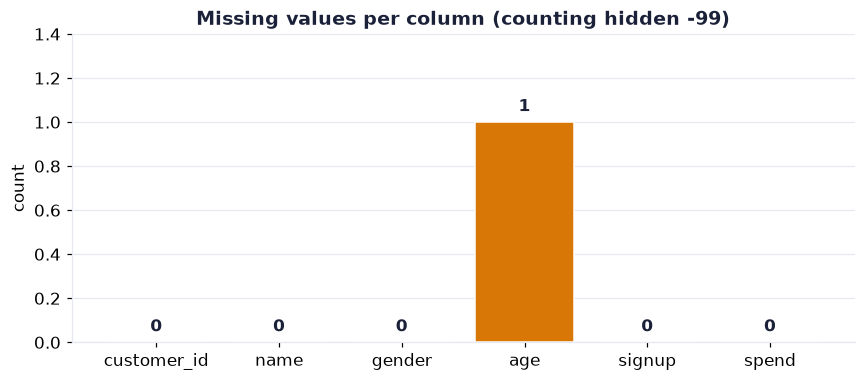

In [4]:
print("explicit NaNs per column:"); print(df.isna().sum())

sentinel = (df["age"] == -99).sum()
print(f"\n-99 sentinels in age that isna() MISSED: {sentinel}")
print(f"naive mean age (with -99): {df['age'].mean():.1f}   <- nonsense")
print(f"mean age treating -99 as missing: {df.loc[df['age']!=-99, 'age'].mean():.1f}  (still has the 200 problem!)")

# a missingness chart, counting -99 as missing for age
miss = df.isna().sum().astype(float)
miss["age"] += (df["age"] == -99).sum()
fig, ax = plt.subplots(figsize=(8, 3.6))
colors = [AMBER if v>0 else CYAN for v in miss.values]
ax.bar(miss.index, miss.values, color=colors, edgecolor="white")
ax.set_title("Missing values per column (counting hidden -99)"); ax.set_ylabel("count")
ax.set_ylim(0, max(miss.max(),1)*1.4); ax.grid(axis="x", visible=False)
for i,v in enumerate(miss.values): ax.text(i, v+0.05, int(v), ha="center", fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · DUPES & IMPOSSIBLE VALUES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">👯 Duplicated rows and out-of-range checks</div>
<div style="color:#4a5578;margin-top:6px">Two more quick audits: duplicated() flags repeated rows and repeated keys, and a simple range rule flags values that cannot be real. Note these are DETECTED here; deciding what to do is the next chapters and a judgment call.</div>
</div>

In [5]:
print(f"exact duplicate rows : {df.duplicated().sum()}")
print(f"duplicate customer_id: {df['customer_id'].duplicated().sum()}  (id 003 appears twice)")

impossible = ((df["age"] < 0) | (df["age"] > 120)).sum()
print(f"\nages outside 0..120 : {impossible}  -> {list(df.loc[(df['age']<0)|(df['age']>120), 'age'])}")
print("age=0 is ambiguous: a newborn, or a default for missing? Only domain knowledge decides.")

exact duplicate rows : 0
duplicate customer_id: 1  (id 003 appears twice)

ages outside 0..120 : 2  -> [200, -99]
age=0 is ambiguous: a newborn, or a default for missing? Only domain knowledge decides.


<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · A DATA-QUALITY REPORT</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📋 One printout that audits every column</div>
<div style="color:#4a5578;margin-top:6px">Wrap the checks into a small report you can run on any new dataset. It is the cleaning mindset in code: inspect type, completeness, uniqueness, and obvious range problems before trusting a single number.</div>
</div>

In [6]:
def quality_report(frame, missing_codes=(-99, 9999)):
    rows = []
    for col in frame.columns:
        s = frame[col]
        hidden = s.isin(missing_codes).sum() if s.dtype != object else 0
        rows.append({
            "column": col,
            "dtype": str(s.dtype),
            "n_unique": s.nunique(),
            "explicit_NaN": int(s.isna().sum()),
            "hidden_missing": int(hidden),
            "duplicated_vals": int(s.duplicated().sum()),
        })
    return pd.DataFrame(rows)

report = quality_report(df)
print(report.to_string(index=False))
print("\nRun this first on every dataset. The mindset: audit, then clean (on a copy, in a script), then validate.")

     column dtype  n_unique  explicit_NaN  hidden_missing  duplicated_vals
customer_id   str         7             0               0                1
       name   str         7             0               0                1
     gender   str         6             0               0                2
        age int64         8             0               1                0
     signup   str         7             0               0                1
      spend   str         7             0               0                1

Run this first on every dataset. The mindset: audit, then clean (on a copy, in a script), then validate.


## 🔎 Real-World Example: Auditing a Messy Table
The cleaning mindset starts with an **audit**, profile the data and list what is wrong before fixing anything. Here we run that first pass on a deliberately messy customer table: count the duplicate rows and the missing values, scan the age range for impossible values, and see how many ways one city got spelled. The output is a to-do list, not a fix.

shape: 212 rows x 5 columns
duplicate rows: 12
impossible ages (age < 0 or age > 120): 2   [min 0, max 999]
distinct spellings of city: 20   (should be 5)
missing values per column:
customer_id     0
city           11
age            15
signup_date     0
total_spend     9


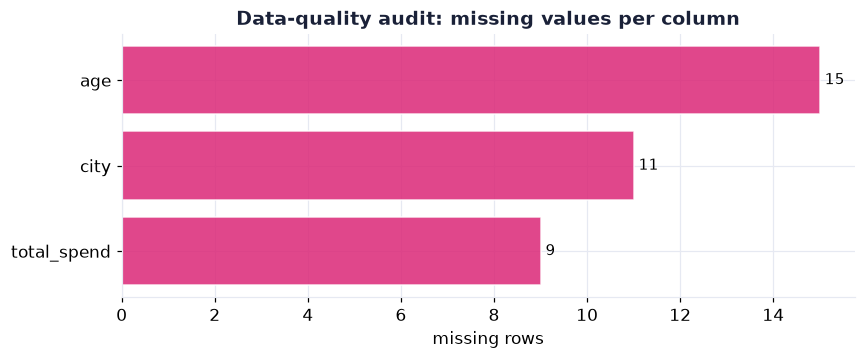

In [7]:
# --- Real-World beat: profile a messy table before touching it ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    raw = pd.read_excel("../../data/the-data-cleaning-mindset--messy_customers.xlsx", sheet_name="Data")
except FileNotFoundError: raw = pd.read_excel(BASE+"the-data-cleaning-mindset--messy_customers.xlsx", sheet_name="Data")
print(f"shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print(f"duplicate rows: {raw.duplicated().sum()}")
print(f"impossible ages (age < 0 or age > 120): {((raw.age < 0) | (raw.age > 120)).sum()}   [min {raw.age.min():.0f}, max {raw.age.max():.0f}]")
print(f"distinct spellings of city: {raw.city.nunique()}   (should be 5)")
print("missing values per column:"); print(raw.isna().sum().to_string())
miss = raw.isna().sum(); miss = miss[miss > 0].sort_values()
fig, ax = plt.subplots(figsize=(8,3.4))
ax.barh(miss.index, miss.values, color=PINK, alpha=0.85, edgecolor="white")
for i, v in enumerate(miss.values): ax.text(v, i, f" {v}", va="center", fontsize=10)
ax.set_title("Data-quality audit: missing values per column"); ax.set_xlabel("missing rows")
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li><b>Look before you trust</b>: info(), dtypes, and describe() surface wrong types and impossible values fast.</li>
<li><b>value_counts()</b> exposes inconsistent categories; check for hidden <b>whitespace</b> too.</li>
<li><b>Hidden missing codes</b> (-99, 9999, 0) slip past isna() and poison naive statistics.</li>
<li><b>duplicated()</b> and simple <b>range checks</b> catch repeated rows and impossible values.</li>
<li>Wrap it all in a <b>quality report</b>: audit first, then clean on a copy, in a script, and validate.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>